   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

/tmp/ipython-input-1125574898.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-1125574898.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

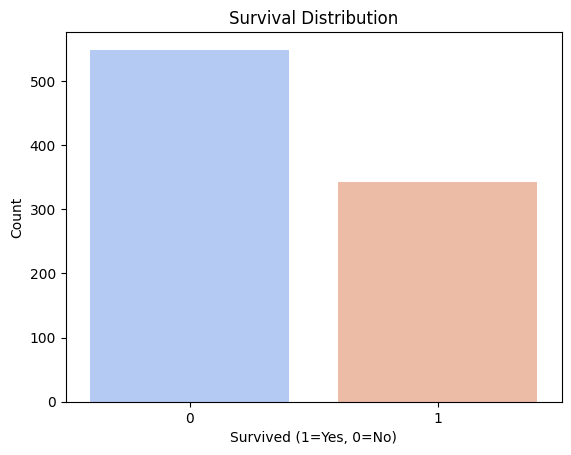

Train size: 712, Test size: 179

📊 2-WAY SPLIT RESULTS
Accuracy: 0.799

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



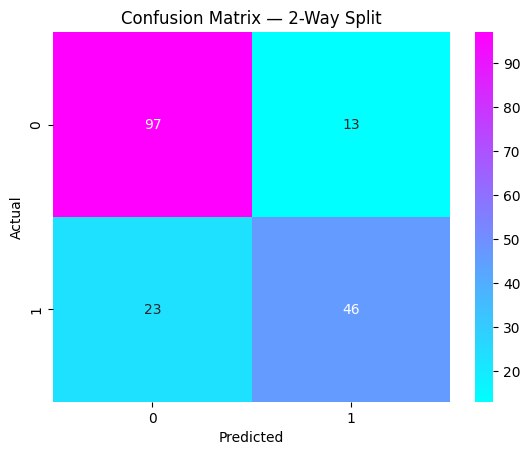


Train: 534, Validation: 178, Test: 179

Validation Accuracy: 0.787
Test Accuracy (after validation): 0.788


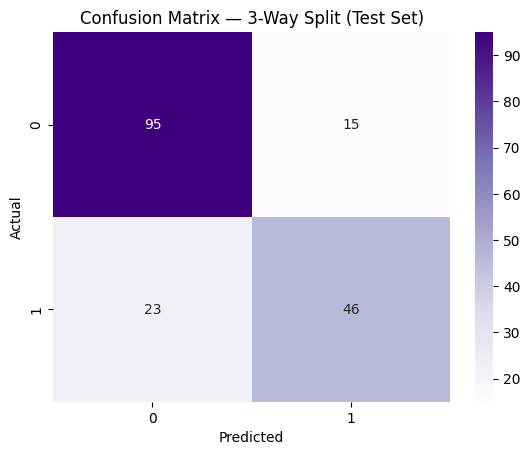

In [2]:
# 📚 Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1️⃣ Load dataset
df = pd.read_csv("Titanic-Dataset.csv")  # or train.csv
print(df.head())
print(df.info())

# 2️⃣ Select useful columns
cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Survived']
df = df[cols]

# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Encode categorical features
label = LabelEncoder()
df['Sex'] = label.fit_transform(df['Sex'])     # male=1, female=0
df['Embarked'] = label.fit_transform(df['Embarked'])

# Features & target
X = df.drop('Survived', axis=1)
y = df['Survived']

# 3️⃣ Visualize target distribution
sns.countplot(x=y, palette="coolwarm")
plt.title("Survival Distribution")
plt.xlabel("Survived (1=Yes, 0=No)")
plt.ylabel("Count")
plt.show()

# 4️⃣ ---- 2-WAY SPLIT (Train/Test) ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("\n📊 2-WAY SPLIT RESULTS")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="cool", fmt="d")
plt.title("Confusion Matrix — 2-Way Split")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 5️⃣ ---- 3-WAY SPLIT (Train/Validation/Test) ----
# First split off test set
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Then split train+validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)
# (60/20/20)

print(f"\nTrain: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Train model
model2 = LogisticRegression(max_iter=2000)
model2.fit(X_train, y_train)

# Validation
y_val_pred = model2.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"\nValidation Accuracy: {val_acc:.3f}")

# Test
y_test_pred = model2.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy (after validation): {test_acc:.3f}")

# Confusion matrix for test set
cm2 = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm2, annot=True, cmap="Purples", fmt="d")
plt.title("Confusion Matrix — 3-Way Split (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Accuracy: 74.13 %


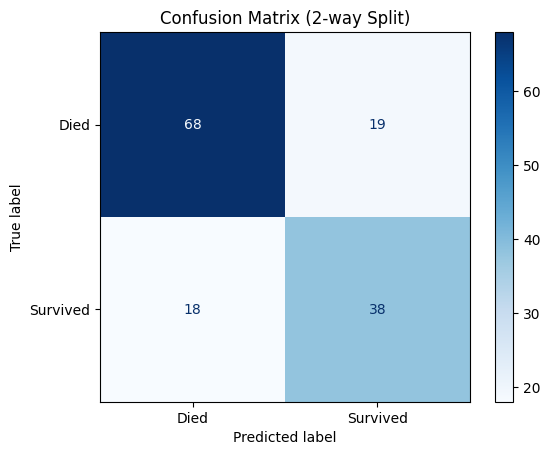

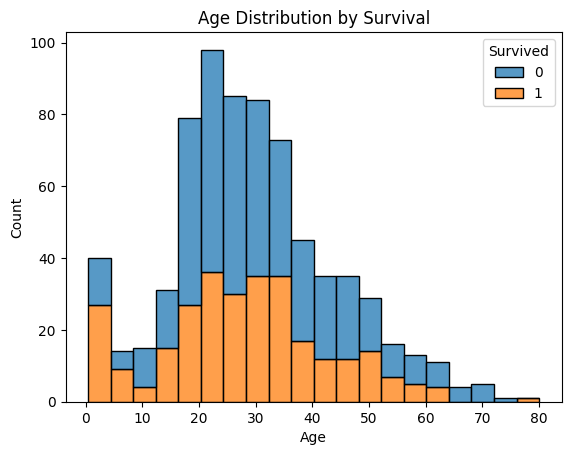

In [4]:
# --- 2-WAY SPLIT: TITANIC DATASET ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic dataset
df = pd.read_csv("Titanic-Dataset.csv")  # or train.csv

# Select useful features
features = ['Pclass', 'Sex', 'Age', 'Fare']
df = df[features + ['Survived']].dropna()

# Convert categorical to numeric
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Split data
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Bayesian classifier
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc * 100, 2), "%")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Died', 'Survived'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (2-way Split)")
plt.show()

# Histogram of features
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', bins=20)
plt.title("Age Distribution by Survival")
plt.show()


Validation Accuracy: 77.62 %
Test Accuracy: 74.83 %


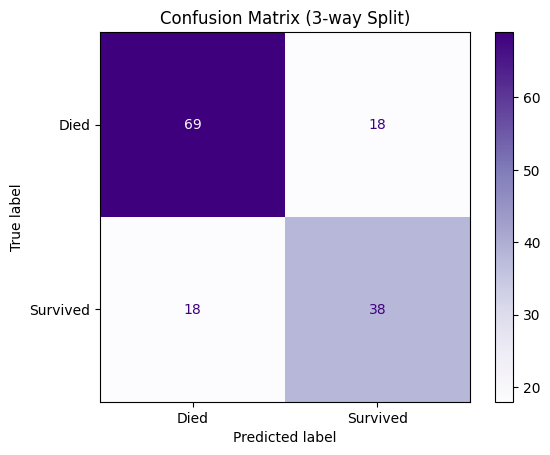

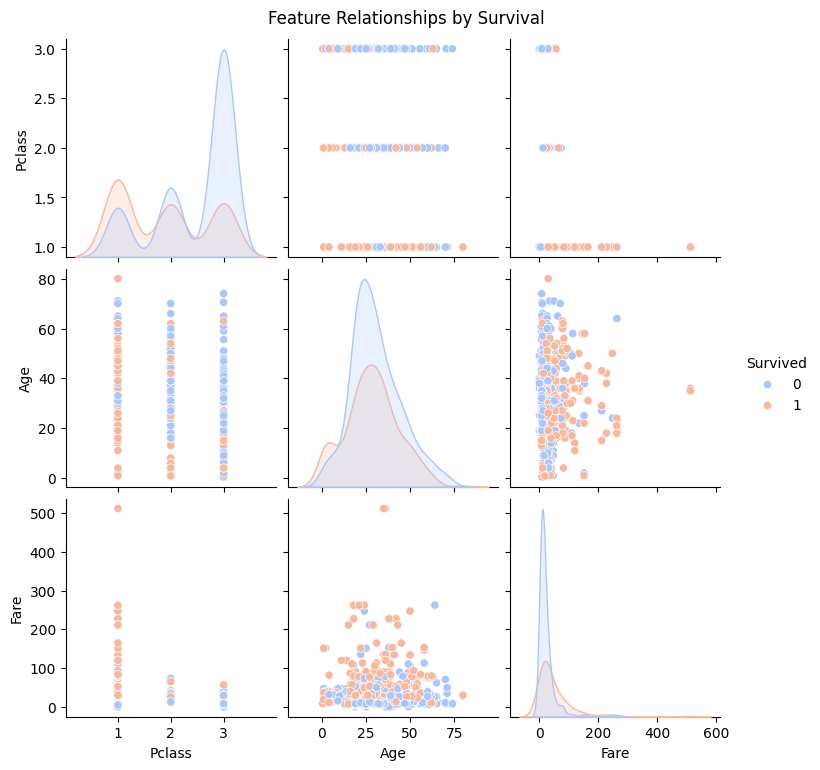

In [5]:
# --- 3-WAY SPLIT: TITANIC DATASET ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Titanic-Dataset.csv")  # or train.csv
features = ['Pclass', 'Sex', 'Age', 'Fare']
df = df[features + ['Survived']].dropna()
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X = df[features]
y = df['Survived']

# 60% train, 20% val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

# Train
model = GaussianNB()
model.fit(X_train, y_train)

# Validate
y_val_pred = model.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print("Validation Accuracy:", round(val_acc * 100, 2), "%")

# Test
y_test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", round(test_acc * 100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Died', 'Survived'])
disp.plot(cmap='Purples')
plt.title("Confusion Matrix (3-way Split)")
plt.show()

# Pairplot visualization
sns.pairplot(df[['Pclass', 'Age', 'Fare', 'Survived']], hue='Survived', palette='coolwarm')
plt.suptitle("Feature Relationships by Survival", y=1.02)
plt.show()
